# Machine Learning-Based Stroke Prediction: Evaluating the Impact of Data Preprocessing Techniques

## 01_EDA: Exploratory Data Analysis

In this notebook, I first explore the stroke dataset. I check its structure, data quality, and main patterns before cleaning the data or building any models.


## 1. Dataset Overview

The dataset contains patient details such as age, health conditions, lifestyle, and stroke status. The target column is `stroke`: `1` means the patient had a stroke, and `0` means they did not. I start by checking the data types, missing values, and target balance.


In [1]:
from pathlib import Path
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "healthcare-dataset-stroke-data.csv"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
display(df.head())

Dataset path: C:\Users\11315\Documents\Stroke_Project\data\healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Dataset Shape

I check the number of rows and columns to get a quick idea of the dataset size.


In [2]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

shape_table = pd.DataFrame({
    "metric": ["Rows", "Columns"],
    "value": [rows, columns]
})
display(shape_table)

Number of rows: 5110
Number of columns: 12


,metric,value
0,Rows,5110
1,Columns,12


## 3. Dataset Information (df.info)

`df.info()` shows the column names, data types, and non-null counts. This helps me find columns that need encoding, scaling, or missing-value treatment.


In [3]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

column_information = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "unique_values": df.nunique(dropna=True).values
})
display(column_information)

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB



,column,dtype,non_null_count,missing_count,unique_values
0,id,int64,5110,0,5110
1,gender,str,5110,0,3
2,age,float64,5110,0,104
3,hypertension,int64,5110,0,2
4,heart_disease,int64,5110,0,2
5,ever_married,str,5110,0,2
6,work_type,str,5110,0,5
7,Residence_type,str,5110,0,2
8,avg_glucose_level,float64,5110,0,3979
9,bmi,float64,4909,201,418


## 4. Descriptive Statistics

I use summary statistics to check the range and spread of the numeric columns. I also check the categorical columns to see which groups are common or rare.


In [4]:
print("Numeric descriptive statistics")
display(df.describe().T)

print("Categorical descriptive statistics")
display(df.describe(include="object").T)

Numeric descriptive statistics


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


Categorical descriptive statistics


C:\Users\11315\AppData\Local\Temp\ipykernel_46676\1455933721.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


## 5. Missing Value Analysis

Missing values can affect the later models, so I check which columns contain them and how they are spread across the dataset.


,missing_count
bmi,201
id,0
age,0
gender,0
hypertension,0
heart_disease,0
work_type,0
ever_married,0
Residence_type,0
avg_glucose_level,0


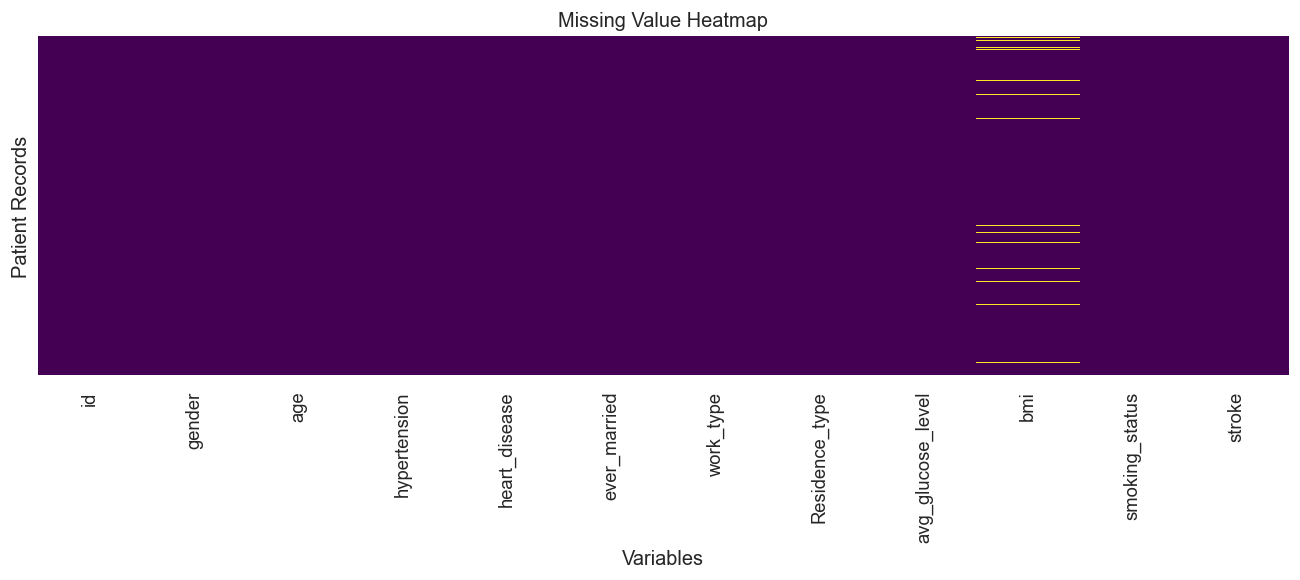

In [5]:
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts.to_frame(name="missing_count"))

plt.figure(figsize=(11, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Heatmap")
plt.xlabel("Variables")
plt.ylabel("Patient Records")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_value_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Missing Value Percentage Table

I also show missing values as percentages. This makes it easier to judge how serious the problem is.


In [6]:
missing_percentage_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percentage", ascending=False)

display(missing_percentage_table)

,missing_count,missing_percentage
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


## 7. Stroke Class Distribution

I check the target balance because stroke cases may be much less common than non-stroke cases. If the classes are imbalanced, accuracy alone will not be enough. Recall, precision, F1 score, and PR-AUC will be more useful.


,stroke,count,percentage
0,0,4861,95.13
1,1,249,4.87


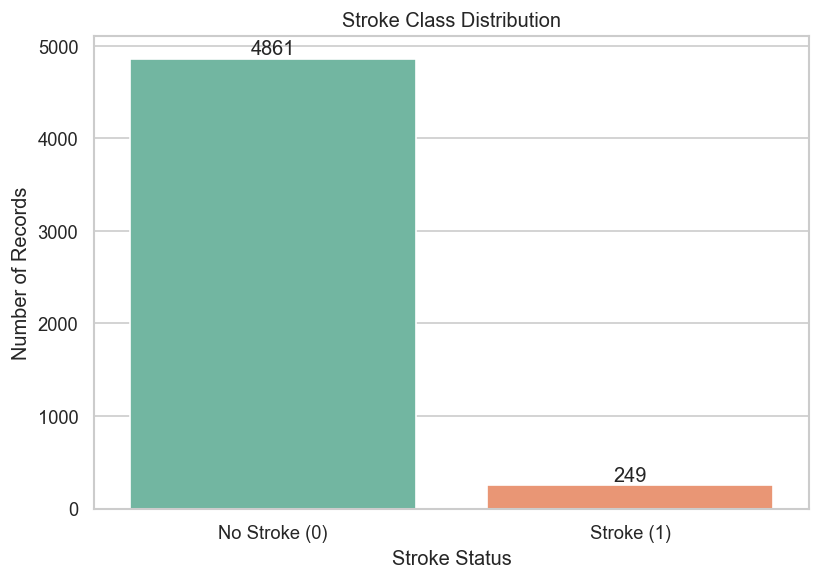

In [7]:
stroke_distribution = df["stroke"].value_counts().sort_index()
stroke_distribution_table = pd.DataFrame({
    "stroke": stroke_distribution.index,
    "count": stroke_distribution.values,
    "percentage": (stroke_distribution.values / len(df) * 100).round(2)
})
display(stroke_distribution_table)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="stroke", hue="stroke", palette="Set2", legend=False)
ax.set_title("Stroke Class Distribution")
ax.set_xlabel("Stroke Status")
ax.set_ylabel("Number of Records")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Stroke (0)", "Stroke (1)"])
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "stroke_distribution_chart.png", bbox_inches="tight")
plt.show()

## 8. Age Distribution

Age is likely to be an important feature for stroke prediction. I plot its distribution to see the age range and whether some age groups appear more often than others.


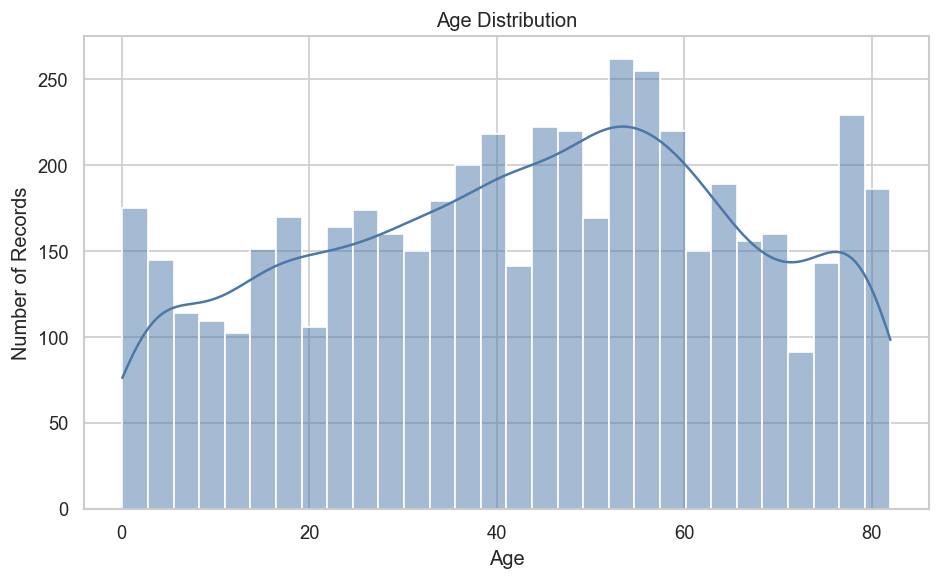

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="#4C78A8")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_distribution_histogram.png", bbox_inches="tight")
plt.show()

## 9. BMI Distribution

BMI contains missing values, so I first look at the values that are available. The shape of this distribution will help me choose a suitable imputation method later.


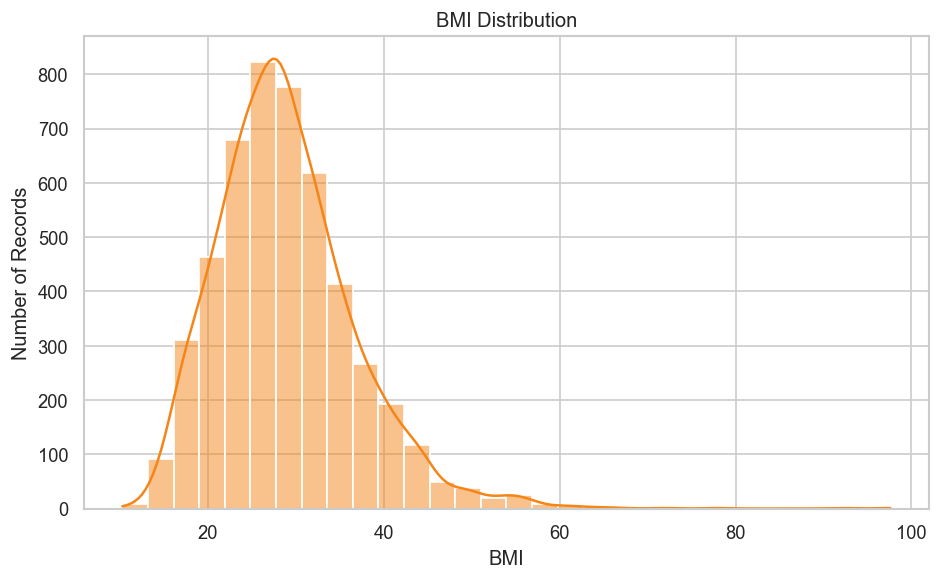

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="bmi", bins=30, kde=True, color="#F58518")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_distribution_histogram.png", bbox_inches="tight")
plt.show()

## 10. BMI Boxplot

The boxplot gives a clearer view of the BMI median, spread, and possible outliers. I do not remove these values at this stage because unusual BMI values may still be valid.


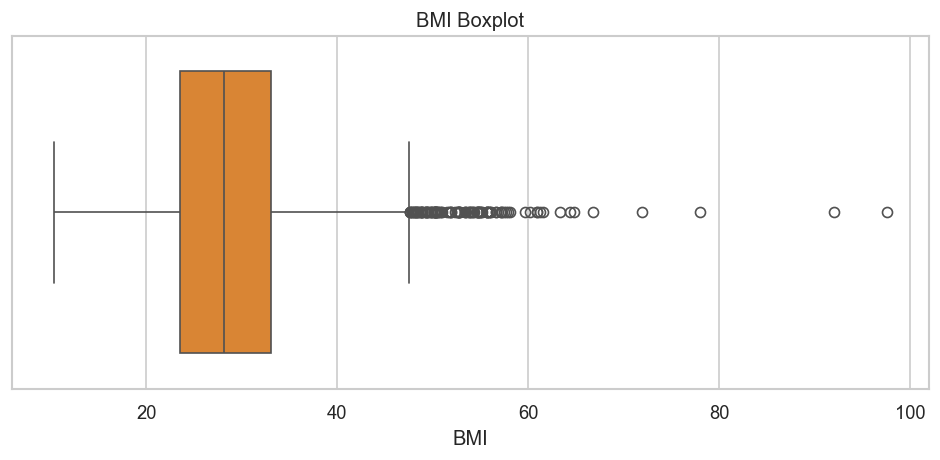

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="bmi", color="#F58518")
plt.title("BMI Boxplot")
plt.xlabel("BMI")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_boxplot.png", bbox_inches="tight")
plt.show()

## 11. Correlation Heatmap

This heatmap shows the linear relationships between numeric columns. I exclude `id` because it is only an identifier. The heatmap is useful for exploration, but correlation does not prove cause and effect.


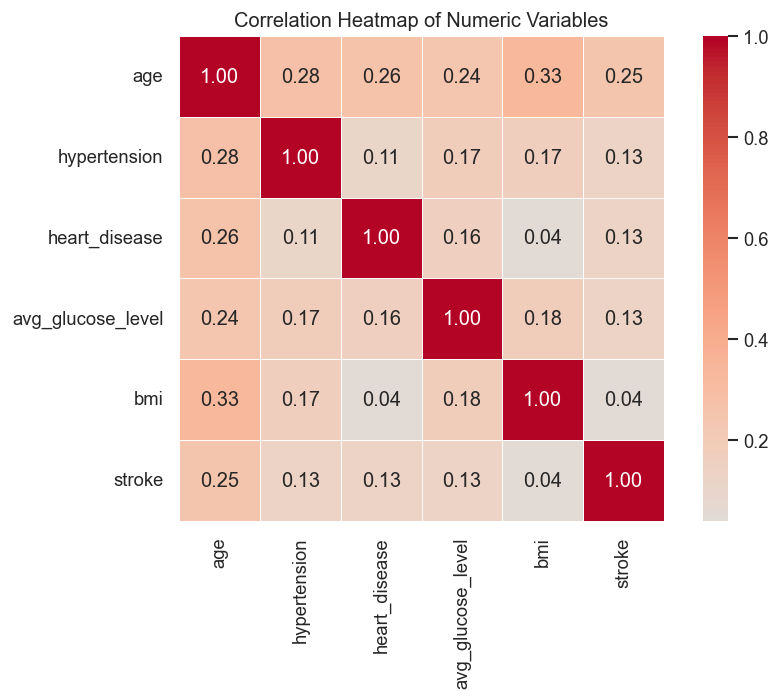

In [11]:
numeric_df = df.select_dtypes(include="number").drop(columns=["id"], errors="ignore")
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 12. EDA Conclusions

The dataset can be used for binary classification, but it needs some cleaning first. The stroke class is much smaller than the non-stroke class, so later model evaluation should focus on recall, precision, F1 score, and PR-AUC instead of accuracy alone.

Most missing values are in the BMI column. Removing every row with a missing BMI could lose useful records, including stroke cases. I will compare several imputation methods in the next notebook.

Age looks useful for prediction. BMI and average glucose level also have some extreme values, but these may be real patient values. I will study them before deciding whether to remove anything.

The next steps are to handle missing BMI values, encode categorical columns, test scaling, and deal with class imbalance during model training.
